## Data Preprocessing — Customer Churn Classification

Pipeline: Drop ID → Handle Missing → Encode Categoricals → Feature Engineering → Split → Scale

### Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler

train = pd.read_csv("/kaggle/input/datasets/muhammadshahidazeem/customer-churn-dataset/customer_churn_dataset-training-master.csv")
test = pd.read_csv("/kaggle/input/datasets/muhammadshahidazeem/customer-churn-dataset/customer_churn_dataset-testing-master.csv")

train_df = pd.concat([train, test], axis = 0)
print(f"Train shape: {train_df.shape}")


Train shape: (505207, 12)


### 1. Drop cột không cần thiết

- `CustomerID` là cột định danh, không mang thông tin dự đoán
- Nếu giữ lại, model sẽ "memorize" ID → overfitting

In [4]:
drop_cols = ["CustomerID"]

train_df = train_df.drop(columns=drop_cols)

print(f"Train columns: {train_df.columns.tolist()}")
print(f"Train shape sau khi drop: {train_df.shape}")

Train columns: ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']
Train shape sau khi drop: (505207, 11)


### 2. Xử lý Missing Values

- Train có đúng **1 dòng** (index 199295) tất cả cột đều null
- Test **không có** missing values


In [5]:
# Kiểm tra missing trước khi xử lý
print(f"Train missing rows: {train_df.isnull().any(axis=1).sum()}")

# Drop dòng missing
train_df = train_df.dropna()

# Reset index
train_df = train_df.reset_index(drop=True)

print("--- Sau Khi Xử Lý ---")
print(f"Train shape: {train_df.shape}")
print(f"Train missing: {train_df.isnull().sum().sum()}")

Train missing rows: 1
--- Sau Khi Xử Lý ---
Train shape: (505206, 11)
Train missing: 0


### 3. Encode Categorical Features

| Cột | Giá trị | Phương pháp | Lý do |
|-----|---------|-------------|-------|
| `Gender` | Female, Male | LabelEncoder | Binary → 0/1 |
| `Subscription Type` | Basic, Standard, Premium | OrdinalEncoder | Có thứ bậc tự nhiên |
| `Contract Length` | Monthly, Quarterly, Annual | OrdinalEncoder | Có thứ bậc tự nhiên |

In [6]:
# Kiểm tra các giá trị unique trước khi encode
print("Gender:", train_df["Gender"].unique())
print("Subscription Type:", train_df["Subscription Type"].unique())
print("Contract Length:", train_df["Contract Length"].unique())

Gender: ['Female' 'Male']
Subscription Type: ['Standard' 'Basic' 'Premium']
Contract Length: ['Annual' 'Monthly' 'Quarterly']


In [7]:
# --- Gender: Binary → LabelEncoder ---
le_gender = LabelEncoder()
train_df["Gender"] = le_gender.fit_transform(train_df["Gender"])

print(f"Gender mapping: {dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_)))}")

Gender mapping: {'Female': np.int64(0), 'Male': np.int64(1)}


In [8]:
# --- Subscription Type: Ordinal (Basic = 0 < Standard = 1 < Premium = 2) ---
sub_categories = [["Basic", "Standard", "Premium"]]
oe_sub = OrdinalEncoder(categories=sub_categories)

train_df["Subscription Type"] = oe_sub.fit_transform(train_df[["Subscription Type"]])

print(f"Subscription Type mapping: Basic=0, Standard=1, Premium=2")
print(f"Unique values: {sorted(train_df['Subscription Type'].unique())}")

Subscription Type mapping: Basic=0, Standard=1, Premium=2
Unique values: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]


In [9]:
# --- Contract Length: Ordinal (Monthly=0 < Quarterly=1 < Annual=2) ---
contract_categories = [["Monthly", "Quarterly", "Annual"]]
oe_contract = OrdinalEncoder(categories=contract_categories)

train_df["Contract Length"] = oe_contract.fit_transform(train_df[["Contract Length"]])

print(f"Contract Length mapping: Monthly=0, Quarterly=1, Annual=2")
print(f"Unique values: {sorted(train_df['Contract Length'].unique())}")

Contract Length mapping: Monthly=0, Quarterly=1, Annual=2
Unique values: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]


In [10]:
# Kiểm tra toàn bộ dtypes sau khi encode
print("=== Data types sau encoding ===")
print(train_df.dtypes)
print(f"\nTrain shape: {train_df.shape}")
train_df.head()

=== Data types sau encoding ===
Age                  float64
Gender                 int64
Tenure               float64
Usage Frequency      float64
Support Calls        float64
Payment Delay        float64
Subscription Type    float64
Contract Length      float64
Total Spend          float64
Last Interaction     float64
Churn                float64
dtype: object

Train shape: (505206, 11)


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,0,39.0,14.0,5.0,18.0,1.0,2.0,932.0,17.0,1.0
1,65.0,0,49.0,1.0,10.0,8.0,0.0,0.0,557.0,6.0,1.0
2,55.0,0,14.0,4.0,6.0,18.0,0.0,1.0,185.0,3.0,1.0
3,58.0,1,38.0,21.0,7.0,7.0,1.0,0.0,396.0,29.0,1.0
4,23.0,1,32.0,20.0,5.0,8.0,0.0,0.0,617.0,20.0,1.0


### 4. Feature Engineering

Tạo các feature mới dựa trên domain knowledge:

| Feature | Công thức | Ý nghĩa |
|---------|----------|----------|
| `Spend_per_Tenure` | Total Spend / Tenure | Chi tiêu TB mỗi tháng |
| `Usage_per_Tenure` | Usage Frequency / Tenure | Mức sử dụng theo thời gian |
| `Support_per_Tenure` | Support Calls / Tenure | Tần suất gọi support |
| `Delay_x_Support` | Payment Delay × Support Calls | Risk interaction feature |

In [11]:
def add_features(df):
    """Tạo các features mới cho DataFrame."""
    df = df.copy()
    
    # Chi tiêu trung bình mỗi nhiệm kỳ 
    df["Spend_per_Tenure"] = df["Total Spend"] / df["Tenure"]
    
    # Mức sử dụng dịch vụ theo thời gian
    df["Usage_per_Tenure"] = df["Usage Frequency"] / df["Tenure"]
    
    # Tần suất liên hệ hỗ trợ theo thời gian
    df["Support_per_Tenure"] = df["Support Calls"] / df["Tenure"]
    
    # Interaction: khách hàng vừa trễ hạn vừa gọi support nhiều => risk cao
    df["Delay_x_Support"] = df["Payment Delay"] * df["Support Calls"]
    
    return df

train_df = add_features(train_df)

print(f"Train shape sau feature engineering: {train_df.shape}")
print(f"\nCác cột mới: {train_df.columns.tolist()[-4:]}")
train_df.head()

Train shape sau feature engineering: (505206, 15)

Các cột mới: ['Spend_per_Tenure', 'Usage_per_Tenure', 'Support_per_Tenure', 'Delay_x_Support']


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Spend_per_Tenure,Usage_per_Tenure,Support_per_Tenure,Delay_x_Support
0,30.0,0,39.0,14.0,5.0,18.0,1.0,2.0,932.0,17.0,1.0,23.897436,0.358974,0.128205,90.0
1,65.0,0,49.0,1.0,10.0,8.0,0.0,0.0,557.0,6.0,1.0,11.367347,0.020408,0.204082,80.0
2,55.0,0,14.0,4.0,6.0,18.0,0.0,1.0,185.0,3.0,1.0,13.214286,0.285714,0.428571,108.0
3,58.0,1,38.0,21.0,7.0,7.0,1.0,0.0,396.0,29.0,1.0,10.421053,0.552632,0.184211,49.0
4,23.0,1,32.0,20.0,5.0,8.0,0.0,0.0,617.0,20.0,1.0,19.281250,0.625000,0.156250,40.0


In [12]:
# Kiểm tra có inf hay NaN sau feature engineering không
print("--- Kiểm tra giá trị bất thường ---")
print(f"Inf values in train: {np.isinf(train_df.select_dtypes(include=[np.number])).sum().sum()}")
print(f"NaN values in train: {train_df.isnull().sum().sum()}")

--- Kiểm tra giá trị bất thường ---
Inf values in train: 0
NaN values in train: 0


### 5. Tách dữ liệu: Train / Validation / Test

- **Train** (80%): huấn luyện model
- **Validation** (20%): đánh giá & tune hyperparameters
- **Test**: đánh giá cuối cùng (chỉ dùng 1 lần)
- Dùng `stratify` để giữ tỷ lệ class balance

In [13]:
# Tách features và target
TARGET = "Churn"

X_train_full = train_df.drop(columns=[TARGET])
y_train_full = train_df[TARGET]

# Lưu tên features để dùng cho feature importance
feature_names = X_train_full.columns.tolist()
print(f"Feature names ({len(feature_names)}): {feature_names}")

Feature names (14): ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Spend_per_Tenure', 'Usage_per_Tenure', 'Support_per_Tenure', 'Delay_x_Support']


In [14]:
# Split: 80% train, 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    random_state=42,
    # giữ tỉ lệ Churn/Not Churn
    stratify=y_train_full
)

print(f"X_train: {X_train.shape} | y_train Churn ratio: {y_train.mean():.4f}")
print(f"X_val:  {X_val.shape}  | y_val Churn ratio:  {y_val.mean():.4f}")

X_train: (404164, 14) | y_train Churn ratio: 0.5552
X_val:  (101042, 14)  | y_val Churn ratio:  0.5552


### 6. Feature Scaling

- Dùng `StandardScaler`: chuẩn hóa về mean=0, std=1


In [15]:
scaler = StandardScaler()

# chỉ fit trên tập train để tránh data leakage
X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=feature_names)

y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)

print("=== Thống kê X_train sau scaling ===")
print(X_train_scaled.describe().round(4))

=== Thống kê X_train sau scaling ===
               Age       Gender       Tenure  Usage Frequency  Support Calls  \
count  404164.0000  404164.0000  404164.0000      404164.0000    404164.0000   
mean        0.0000       0.0000       0.0000          -0.0000         0.0000   
std         1.0000       1.0000       1.0000           1.0000         1.0000   
min        -1.7126      -1.1167      -1.7616          -1.7085        -1.2225   
25%        -0.8445      -1.1167      -0.8914          -0.8965        -0.9034   
50%         0.0235       0.8955       0.0369           0.0314        -0.2652   
75%         0.7338       0.8955       0.8491           0.8433         0.6921   
max         1.9964       0.8955       1.6613           1.6552         1.9685   

       Payment Delay  Subscription Type  Contract Length  Total Spend  \
count    404164.0000        404164.0000      404164.0000  404164.0000   
mean          0.0000            -0.0000           0.0000      -0.0000   
std           1.0000   

### 8. Tổng Kết

In [14]:
print("=" * 60)
print("PREPROCESSING SUMMARY")
print("=" * 60)
print(f"\n Dataset sizes:")
print(f"   Train:      {X_train_scaled.shape}")
print(f"   Validation:       {X_val_scaled.shape}")
print(f"\n Features ({len(feature_names)}):")
for i, feat in enumerate(feature_names, 1):
    print(f"   {i:2d}. {feat}")
print(f"\n Target: Churn (binary)")
print(f"   Train Churn ratio:  {y_train.mean():.4f}")
print(f"   Validation Churn ratio:   {y_val.mean():.4f}")
print(f"\n Missing values: 0")

PREPROCESSING SUMMARY

 Dataset sizes:
   Train:      (404164, 14)
   Validation:       (101042, 14)

 Features (14):
    1. Age
    2. Gender
    3. Tenure
    4. Usage Frequency
    5. Support Calls
    6. Payment Delay
    7. Subscription Type
    8. Contract Length
    9. Total Spend
   10. Last Interaction
   11. Spend_per_Tenure
   12. Usage_per_Tenure
   13. Support_per_Tenure
   14. Delay_x_Support

 Target: Churn (binary)
   Train Churn ratio:  0.5552
   Validation Churn ratio:   0.5552

 Missing values: 0


---

### Ghi chú cho bước tiếp theo (Model Training)

Các biến sẵn sàng để sử dụng:
- `X_train_scaled`, `y_train` → Huấn luyện model
- `X_val_scaled`, `y_val` → Đánh giá
- `feature_names` → Tên các features (cho feature importance)
- `scaler` → Scaler object (cần save để dùng cho inference)

# Model-ML

# 1. XGBoost

# Import Libraries

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import classification_report, ConfusionMatrixDisplay 
from sklearn.model_selection import RandomizedSearchCV

# Hyperparameter Setup

In [17]:
param_dist = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 6, 9, 12],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2, 0.5],
    'min_child_weight': [1, 3, 5]
}

# Model

In [18]:
# XGBoost
xgb_gpu = XGBClassifier(
    random_state=42, 
    tree_method='hist', 
    device='cuda', 
    eval_metric='logloss'
)

# K-fold = 5
random_search = RandomizedSearchCV(
    estimator=xgb_gpu,
    param_distributions=param_dist,
    n_iter=20, 
    cv=5,
    scoring='accuracy',
    verbose=0, 
    random_state=42,
    n_jobs=1 
)

# Hyperparameter Tuning

In [19]:
random_search.fit(X_train_scaled, y_train)

best_params = random_search.best_params_
best_score = random_search.best_score_

print("\nHyperparameter Tuning Results:")
print(f"Best Score (Accuracy): {best_score:.4f}")
print("Best Parameters:")
for param, val in best_params.items():
    print(f"  - {param}: {val}")


Hyperparameter Tuning Results:
Best Score (Accuracy): 0.9359
Best Parameters:
  - subsample: 0.8
  - n_estimators: 500
  - min_child_weight: 5
  - max_depth: 12
  - learning_rate: 0.01
  - gamma: 0.2
  - colsample_bytree: 0.9


In [20]:
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_val_scaled)

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      0.86      0.92     44943
         1.0       0.90      1.00      0.95     56099

    accuracy                           0.94    101042
   macro avg       0.95      0.93      0.93    101042
weighted avg       0.94      0.94      0.94    101042



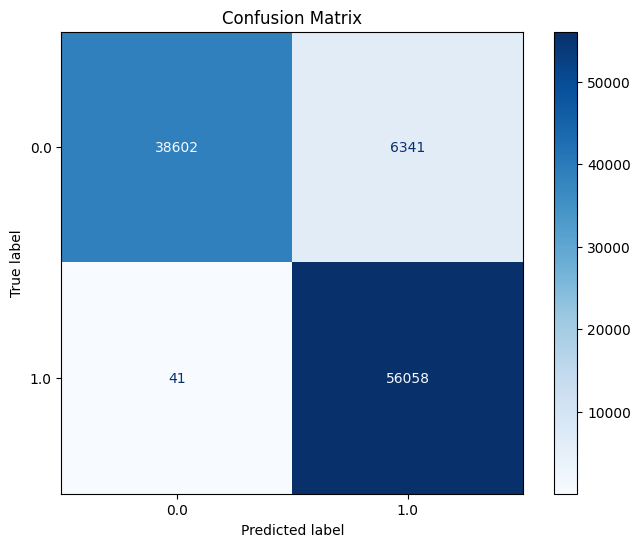

In [21]:
# Vẽ Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, cmap='Blues', values_format='d', ax=ax)
plt.title('Confusion Matrix')
plt.show()

# 2. LightGBM


In [22]:
from lightgbm import LGBMClassifier

# Hyperparameter Setup

In [26]:
param_dist_lgb = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 6, 9, 12],
    'num_leaves': [15, 31, 63, 127], 
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9], 
    'colsample_bytree': [0.7, 0.8, 0.9], 
    'min_child_weight': [1, 3, 5]
}

# Model

In [27]:
# LightGBM
lgb_gpu = LGBMClassifier(
    random_state=42, 
    device_type='gpu', 
    objective='binary',
    metric='binary_logloss',
    verbose=-1 
)

# k=fold = 5
random_search_lgb = RandomizedSearchCV(
    estimator=lgb_gpu,
    param_distributions=param_dist_lgb,
    n_iter=20, 
    cv=5,
    scoring='accuracy',
    verbose=0, 
    random_state=42,
    n_jobs=1 
)

# Hyperparameter Tuning

In [28]:
random_search_lgb.fit(X_train_scaled, y_train)

best_params_lgb = random_search_lgb.best_params_
best_score_lgb = random_search_lgb.best_score_

print("\n--- Hyperparameter Tuning Results ---")
print(f"Best CV Accuracy: {best_score_lgb:.4f}")
print("Best Parameters:")
for param, val in best_params_lgb.items():
    print(f"  - {param}: {val}")

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.



--- Hyperparameter Tuning Results ---
Best CV Accuracy: 0.9355
Best Parameters:
  - subsample: 0.9
  - num_leaves: 63
  - n_estimators: 500
  - min_child_weight: 5
  - max_depth: 12
  - learning_rate: 0.05
  - colsample_bytree: 0.7


In [31]:
best_lgb_model = random_search_lgb.best_estimator_

y_pred_lgb = best_lgb_model.predict(X_val_scaled)

print(classification_report(y_val, y_pred_lgb))

              precision    recall  f1-score   support

         0.0       1.00      0.86      0.92     44943
         1.0       0.90      1.00      0.95     56099

    accuracy                           0.94    101042
   macro avg       0.95      0.93      0.93    101042
weighted avg       0.94      0.94      0.94    101042



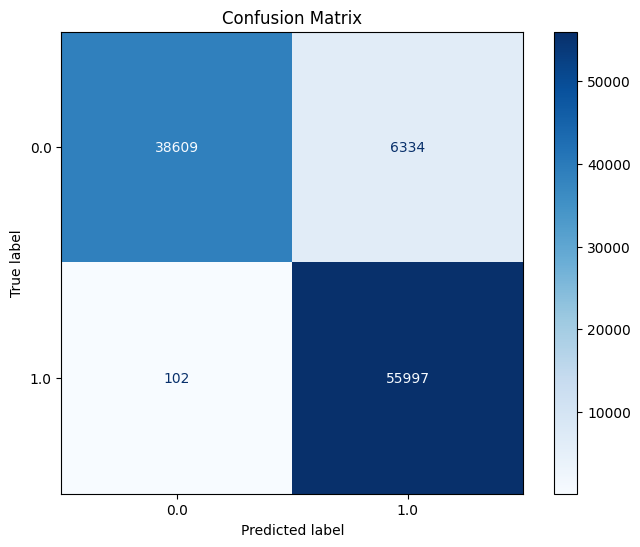

In [32]:
# Vẽ Confusion Matrix cho LightGBM
fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(y_val, y_pred_lgb, cmap='Blues', values_format='d', ax=ax)

plt.title('Confusion Matrix')
plt.show()